<a href="https://colab.research.google.com/github/anunknownpleasure/Erdos-bank-fraud/blob/main/MODELS/train_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Training & Hyperparameter Tuning — Bank Account Fraud (BAF)

This notebook downloads the dataset, preprocesses it, trains four fraud detection models with `RandomizedSearchCV` hyperparameter tuning, and saves all models.

**Note on runtime:** Tuning on 1M rows is slow. By default, search is run on a **20% stratified subsample** of the training set. The best parameters are then used to train on the **full** set. Increase `TUNE_SAMPLE_FRAC` for a more thorough search.

## 1. Imports & Config

In [1]:
!git clone https://github.com/anunknownpleasure/Erdos-bank-fraud


Cloning into 'Erdos-bank-fraud'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 142 (delta 62), reused 127 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (142/142), 1.93 MiB | 44.86 MiB/s, done.
Resolving deltas: 100% (62/62), done.


In [7]:
# Install scikit-optimize for Bayesian optimization
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 13.5 MB/s eta 0:00:00


In [17]:
# Install Optuna
!pip install optuna

import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.9 MB/s eta 0:00:00


In [9]:
import os
import subprocess
import sys

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

DATA_PATH       = "/content/Erdos-bank-fraud/DATA/Base.csv"
PROCESSED_DIR   = "/content/Erdos-bank-fraud/outputs/processed"
MODEL_OUT_DIR   = "/content/Erdos-bank-fraud/outputs"
RANDOM_STATE    = 42
TUNE_SAMPLE_FRAC = 0.20   # fraction of training set used for hyperparameter search
N_ITER           = 10     # number of random parameter combinations per model
CV_FOLDS         = 3      # CV folds inside RandomizedSearchCV

os.makedirs(MODEL_OUT_DIR, exist_ok=True)

## 2. Download Data via Kaggle API

You will be prompted to enter your Kaggle username and API key. Credentials are stored only in memory for this session — nothing is written to disk.

To find your API key: go to **kaggle.com → Settings → API → Create New Token**.

If `Base.csv` already exists in `DATA/`, this cell is skipped entirely.

In [6]:
import getpass

KAGGLE_DATASET = "sgpjesus/bank-account-fraud-dataset-neurips-2022"

if os.path.exists(DATA_PATH):
    print(f"Base.csv already exists at {DATA_PATH} — skipping download.")
else:
    os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
    os.environ["KAGGLE_KEY"]      = getpass.getpass("Kaggle API key: ")

    print("Downloading Base.csv from Kaggle...")
    result = subprocess.run(
        [
            "kaggle",
            "datasets", "download",
            KAGGLE_DATASET,
            "--file", "Base.csv",
            "--path", "/content/Erdos-bank-fraud/DATA/",
            "--unzip",
        ],
        capture_output=True, text=True
    )

    # Clear credentials from environment immediately after use
    os.environ.pop("KAGGLE_USERNAME", None)
    os.environ.pop("KAGGLE_KEY", None)

    if result.returncode != 0:
        print("STDOUT:", result.stdout)
        print("STDERR:", result.stderr)
        raise RuntimeError(
            "Kaggle download failed. Check your credentials and that you have "
            "accepted the dataset terms at kaggle.com/datasets/"
            "sgpjesus/bank-account-fraud-dataset-neurips-2022"
        )
    print("Download complete.")
    print(result.stdout)

Kaggle username: arpithshanbhag
Kaggle API key: ··········
Download complete.
Dataset URL: https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022
License(s): CC-BY-NC-SA-4.0




## 3. Preprocess Data

Runs `DATA/preprocess.py` to apply the temporal split, label-encode categorical features, scale numerical features, and select the most discriminative features.

**Feature selection** mirrors `EDA/fraud_eda.ipynb`: numerical features are ranked by absolute point-biserial correlation with `fraud_bool` (computed on training data only) and the top 15 are kept. All 5 categorical features are always included, consistent with the fraud-rate analysis in both EDA notebooks. `EDA/Bank_fraud_EDA.ipynb` explicitly identified `income`, `customer_age`, `credit_risk_score`, and `keep_alive_session` as the most visually discriminative features — these are captured within the top-15 selection.

Pass `--no-select` to skip feature selection and use all features.

In [8]:
if os.path.exists(os.path.join(PROCESSED_DIR, "X_train.npy")):
    print("Processed arrays already exist — skipping preprocessing.")
else:
    # Check if Base.csv is missing but Base.csv.zip exists, then unzip
    if not os.path.exists(DATA_PATH) and os.path.exists(DATA_PATH + ".zip"):
        print(f"Base.csv not found, but {os.path.basename(DATA_PATH)}.zip exists. Unzipping...")
        # Get the directory of DATA_PATH
        data_dir = os.path.dirname(DATA_PATH)
        unzip_result = subprocess.run(
            ["unzip", "-o", DATA_PATH + ".zip", "-d", data_dir], # -o for overwrite, -d for directory
            capture_output=True, text=True
        )
        if unzip_result.returncode != 0:
            print("Unzipping failed:")
            print(unzip_result.stderr)
            raise RuntimeError("Failed to unzip Base.csv.zip.")
        else:
            print("Unzipping successful.")

    print("Running DATA/preprocess.py...")
    result = subprocess.run(
        [sys.executable, "/content/Erdos-bank-fraud/DATA/preprocess.py"],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Preprocessing failed.")

Base.csv not found, but Base.csv.zip exists. Unzipping...
Unzipping successful.
Running DATA/preprocess.py...
Loaded 1,000,000 rows, 11029 frauds (1.103% fraud rate)

Temporal split by month:
  Train (months 1-5) : 794,989  fraud rate: 0.0103
  Val   (month 6)    : 108,168  fraud rate: 0.0134
  Test  (months 7-8) :  96,843  fraud rate: 0.0147

Feature selection — top 15 numerical by |corr with fraud_bool|:
  Feature                                    |corr|
  --------------------------------------------------
  credit_risk_score                          0.0667
  proposed_credit_limit                      0.0650
  customer_age                               0.0626
  keep_alive_session                         0.0481
  income                                     0.0431
  date_of_birth_distinct_emails_4w           0.0428
  device_distinct_emails_8w                  0.0374
  name_email_similarity                      0.0358
  has_other_cards                            0.0331
  current_address

## 4. Load Processed Data

In [4]:
X_train = np.load(f"{PROCESSED_DIR}/X_train.npy", allow_pickle=True)
X_val   = np.load(f"{PROCESSED_DIR}/X_val.npy",   allow_pickle=True)
X_test  = np.load(f"{PROCESSED_DIR}/X_test.npy",  allow_pickle=True)
y_train = np.load(f"{PROCESSED_DIR}/y_train.npy", allow_pickle=True)
y_val   = np.load(f"{PROCESSED_DIR}/y_val.npy",   allow_pickle=True)
y_test  = np.load(f"{PROCESSED_DIR}/y_test.npy",  allow_pickle=True)

# Load feature names saved by preprocess.py
feature_cols = joblib.load(f"{PROCESSED_DIR}/feature_cols.joblib")

neg, pos = np.bincount(y_train.astype(int))
scale_pos_weight = neg / pos

print(f"Train : {len(y_train):>8,}  fraud rate: {y_train.mean():.4f}")
print(f"Val   : {len(y_val):>8,}  fraud rate: {y_val.mean():.4f}")
print(f"Test  : {len(y_test):>8,}  fraud rate: {y_test.mean():.4f}")
print(f"\nFeatures : {len(feature_cols)}  →  {feature_cols}")
print(f"scale_pos_weight : {scale_pos_weight:.1f}")

# Stratified subsample for hyperparameter search
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=TUNE_SAMPLE_FRAC,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
print(f"\nTuning subsample : {len(y_tune):,}  fraud rate: {y_tune.mean():.4f}")

Train :  794,989  fraud rate: 0.0103
Val   :  108,168  fraud rate: 0.0134
Test  :   96,843  fraud rate: 0.0147

Features : 20  →  ['credit_risk_score', 'proposed_credit_limit', 'customer_age', 'keep_alive_session', 'income', 'date_of_birth_distinct_emails_4w', 'device_distinct_emails_8w', 'name_email_similarity', 'has_other_cards', 'current_address_months_count', 'phone_home_valid', 'email_is_free', 'prev_address_months_count', 'intended_balcon_amount', 'foreign_request', 'payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
scale_pos_weight : 96.5

Tuning subsample : 158,997  fraud rate: 0.0103


## 5. Define Hyperparameter Grids

Edit these distributions to widen or narrow the search space.

In [10]:
param_grids = {
    "LogisticRegression": {
        "C":      [0.001, 0.01, 0.1, 1, 10, 100],
        "solver": ["lbfgs", "liblinear"],
    },
    "RandomForest": {
        "n_estimators":      [100, 200, 300],
        "max_depth":         [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "max_features":      ["sqrt", "log2"],
    },
    "LightGBM": {
        "n_estimators":      Integer(100, 1000),
        "learning_rate":     Real(0.01, 0.2, prior='log-uniform'),
        "num_leaves":        Integer(15, 127),
        "min_child_samples": Integer(20, 100),
        "subsample":         Real(0.7, 1.0, prior='uniform'),
    },
    "XGBoost": {
        "n_estimators":     Integer(100, 1000),
        "learning_rate":    Real(0.01, 0.2, prior='log-uniform'),
        "max_depth":        Integer(4, 8),
        "subsample":        Real(0.7, 1.0, prior='uniform'),
        "colsample_bytree": Real(0.7, 1.0, prior='uniform'),
    },
}

base_models = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ),
    "LightGBM": lgb.LGBMClassifier(
        scale_pos_weight=scale_pos_weight, n_jobs=-1,
        random_state=RANDOM_STATE, verbose=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0
    ),
}

### 5.6. Optuna Objective Function Definitions

In [15]:
def objective(trial, model_name, X, y, X_val, y_val, cv_folds, random_state, scale_pos_weight):
    model_config = {}
    if model_name == "LogisticRegression":
        C = trial.suggest_loguniform('C', 1e-4, 1e2)
        solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
        model_config = {
            "C": C,
            "solver": solver,
            "class_weight": "balanced",
            "max_iter": 1000,
            "random_state": random_state
        }
        model = LogisticRegression(**model_config)
    elif model_name == "RandomForest":
        n_estimators = trial.suggest_int('n_estimators', 100, 300)
        max_depth = trial.suggest_categorical('max_depth', [None, 10, 20, 30])
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
        model_config = {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "max_features": max_features,
            "class_weight": "balanced",
            "n_jobs": -1,
            "random_state": random_state
        }
        model = RandomForestClassifier(**model_config)
    elif model_name == "LightGBM":
        n_estimators = trial.suggest_int('n_estimators', 100, 1000)
        learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.2)
        num_leaves = trial.suggest_int('num_leaves', 15, 127)
        min_child_samples = trial.suggest_int('min_child_samples', 20, 100)
        subsample = trial.suggest_uniform('subsample', 0.7, 1.0)
        model_config = {
            "n_estimators": n_estimators,
            "learning_rate": learning_rate,
            "num_leaves": num_leaves,
            "min_child_samples": min_child_samples,
            "subsample": subsample,
            "scale_pos_weight": scale_pos_weight,
            "n_jobs": -1,
            "random_state": random_state,
            "verbose": -1
        }
        model = lgb.LGBMClassifier(**model_config)
    elif model_name == "XGBoost":
        n_estimators = trial.suggest_int('n_estimators', 100, 1000)
        learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.2)
        max_depth = trial.suggest_int('max_depth', 4, 8)
        subsample = trial.suggest_uniform('subsample', 0.7, 1.0)
        colsample_bytree = trial.suggest_uniform('colsample_bytree', 0.7, 1.0)
        model_config = {
            "n_estimators": n_estimators,
            "learning_rate": learning_rate,
            "max_depth": max_depth,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "scale_pos_weight": scale_pos_weight,
            "eval_metric": "aucpr",
            "n_jobs": -1,
            "random_state": random_state,
            "verbosity": 0
        }
        model = xgb.XGBClassifier(**model_config)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    # Train the model on the tuning subsample
    model.fit(X, y)

    # Evaluate on the validation set for AUPRC
    val_proba = model.predict_proba(X_val)[:, 1]
    auprc = average_precision_score(y_val, val_proba)
    return auprc

## 5.5. Initial Model Performance (Before Tuning)

In [6]:
def find_best_f1_threshold(y_true, y_proba):
    """Return the threshold that maximises F1 on the given set."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = np.where(
        (precision + recall) == 0, 0,
        2 * precision * recall / (precision + recall)
    )
    # Check if f1_scores is empty or all zeros
    if f1_scores.size == 0 or np.all(f1_scores == 0):
        return 0.5, 0.0 # Default threshold and F1 if no valid scores

    best_idx = np.argmax(f1_scores[:-1]) # Exclude the last threshold, which is always 1.0
    return thresholds[best_idx], f1_scores[best_idx]


print(f"{'Model':<22} {'Val F1 @0.5':<15} {'Best Val F1':<15} {'Best Thresh'}")
print("-" * 70)

for name, model in base_models.items():
    # Create a fresh instance of the model to ensure default parameters are used
    # (or the ones set in base_models dictionary)
    current_model = model

    print(f"Training initial {name}...")
    current_model.fit(X_train, y_train)

    val_proba = current_model.predict_proba(X_val)[:, 1]

    # F1 at 0.5 threshold
    f1_at_05 = f1_score(y_val, (val_proba >= 0.5).astype(int))

    # Best F1 and its threshold
    best_thresh, best_f1 = find_best_f1_threshold(y_val, val_proba)

    print(f"{name:<22} {f1_at_05:<15.4f} {best_f1:<15.4f} {best_thresh:.4f}")


Model                  Val F1 @0.5     Best Val F1     Best Thresh
----------------------------------------------------------------------
Training initial LogisticRegression...


/tmp/ipykernel_3725/39612653.py:6: RuntimeWarning: invalid value encountered in divide
  2 * precision * recall / (precision + recall)


LogisticRegression     0.0786          0.2086          0.8805
Training initial RandomForest...
RandomForest           0.0041          0.1985          0.1100
Training initial LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_3725/39612653.py:6: RuntimeWarning: invalid value encountered in divide
  2 * precision * recall / (precision + recall)


LightGBM               0.0903          0.2302          0.9269
Training initial XGBoost...
XGBoost                0.1108          0.2323          0.9039


## 6. Hyperparameter Tuning with Optuna

In [19]:
best_params_optuna = {}

# Note: Optuna does not perform CV internally in the same way GridSearchCV/RandomizedSearchCV do.
# The objective function evaluates a single model configuration.
# For fair comparison and to speed up tuning, we will evaluate on the validation set `X_val`, `y_val`.

# If you wish to use cross-validation within Optuna, the objective function would need to be modified
# to perform CV and return the average metric.

for name, model in base_models.items():
    print(f"Tuning {name} with Optuna...")

    # Create a study for each model
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

    # Optimize the objective function
    # n_trials can be adjusted based on desired search thoroughness and time constraints
    study.optimize(
        lambda trial: objective(trial, name, X_tune, y_tune, X_val, y_val, CV_FOLDS, RANDOM_STATE, scale_pos_weight),
        n_trials=N_ITER, # Using N_ITER for consistency, can be set higher for more thorough search
        show_progress_bar=True
    )

    best_params_optuna[name] = study.best_params
    print(f"  Best AUPRC (Val): {study.best_value:.4f}")
    print(f"  Best params   : {study.best_params}\n")

# Update best_params to use results from Optuna
best_params = best_params_optuna

[I 2026-04-24 04:35:14,841] A new study created in memory with name: no-name-9e938b92-1955-45bf-bc59-d09188d02989


Tuning LogisticRegression with Optuna...


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_3725/193757799.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 1e-4, 1e2)


[I 2026-04-24 04:35:15,798] Trial 0 finished with value: 0.12722370879025063 and parameters: {'C': 0.017670169402947963, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.12722370879025063.


...

[I 2026-04-24 04:37:13,805] Trial 7 finished with value: 0.15599665988612518 and parameters: {'n_estimators': 828, 'learning_rate': 0.0249064396938244, 'max_depth': 4, 'subsample': 0.905269907953647, 'colsample_bytree': 0.8320457481218804}. Best is trial 7 with value: 0.15599665988612518.


/tmp/ipykernel_3725/193757799.py:49: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.2)
/tmp/ipykernel_3725/193757799.py:51: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  subsample = trial.suggest_uniform('subsample', 0.7, 1.0)
/tmp/ipykernel_3725/193757799.py:52: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  colsample_bytree = trial.suggest_uniform('colsample_bytree', 0.7, 1.0)


[I 2026-04-24 04:37:14,730] Trial 8 finished with value: 0.1548702830048067 and parameters: {'n_estimators': 209, 'learning_rate': 0.04407984038169244, 'max_depth': 4, 'subsample': 0.9727961206236346, 'colsample_bytree': 0.777633994480005}. Best is trial 7 with value: 0.15599665988612518.


/tmp/ipykernel_3725/193757799.py:49: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.2)
/tmp/ipykernel_3725/193757799.py:51: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  subsample = trial.suggest_uniform('subsample', 0.7, 1.0)
/tmp/ipykernel_3725/193757799.py:52: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  colsample_bytree = trial.suggest_uniform('colsample_bytree', 0.7, 1.0)


[I 2026-04-24 04:37:20,308] Trial 9 finished with value: 0.1359524793151621 and parameters: {'n_estimators': 696, 'learning_rate': 0.02544166090938368, 'max_depth': 6, 'subsample': 0.8640130838029838, 'colsample_bytree': 0.7554563366576581}. Best is trial 7 with value: 0.15599665988612518.
  Best AUPRC (Val): 0.1560
  Best params   : {'n_estimators': 828, 'learning_rate': 0.0249064396938244, 'max_depth': 4, 'subsample': 0.905269907953647, 'colsample_bytree': 0.8320457481218804}



## 7. Train Tuned Models on Full Training Set

In [20]:
def find_best_f1_threshold(y_true, y_proba):
    """Return the threshold that maximises F1 on the given set."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = np.where(
        (precision + recall) == 0, 0,
        2 * precision * recall / (precision + recall)
    )
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx], f1_scores[best_idx]


results = {}

for name, model in base_models.items():
    tuned = model.set_params(**best_params[name])
    tuned.fit(X_train, y_train)

    val_proba   = tuned.predict_proba(X_val)[:, 1]
    val_auprc   = average_precision_score(y_val, val_proba)
    f1_05       = f1_score(y_val, (val_proba >= 0.5).astype(int))
    best_thresh, best_f1 = find_best_f1_threshold(y_val, val_proba)

    results[name] = {
        "model":       tuned,
        "val_auprc":   val_auprc,
        "f1_at_0.5":   f1_05,
        "best_f1":     best_f1,
        "best_thresh": best_thresh,
    }

print(f"{'Model':<22} {'Val AUPRC':<12} {'F1 @0.5':<12} {'Best F1':<12} {'Threshold'}")
print("-" * 72)
for name, r in results.items():
    print(
        f"{name:<22} {r['val_auprc']:<12.4f} "
        f"{r['f1_at_0.5']:<12.4f} {r['best_f1']:<12.4f} {r['best_thresh']:.4f}"
    )

best_name = max(results, key=lambda k: results[k]["val_auprc"])
print(f"\nBest model by Val AUPRC: {best_name}")

/tmp/ipykernel_3725/1998553615.py:6: RuntimeWarning: invalid value encountered in divide
  2 * precision * recall / (precision + recall)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model                  Val AUPRC    F1 @0.5      Best F1      Threshold
------------------------------------------------------------------------
LogisticRegression     0.1279       0.0779       0.2079       0.9034
RandomForest           0.1405       0.1094       0.2193       0.8134
LightGBM               0.1677       0.0959       0.2443       0.8852
XGBoost                0.1718       0.1002       0.2423       0.8988

Best model by Val AUPRC: XGBoost


## 8. Feature Importance — Selected Features

FileNotFoundError: [Errno 2] No such file or directory: '/content/Erdos-bank-fraud/outputs/figures/feature_importance.png'

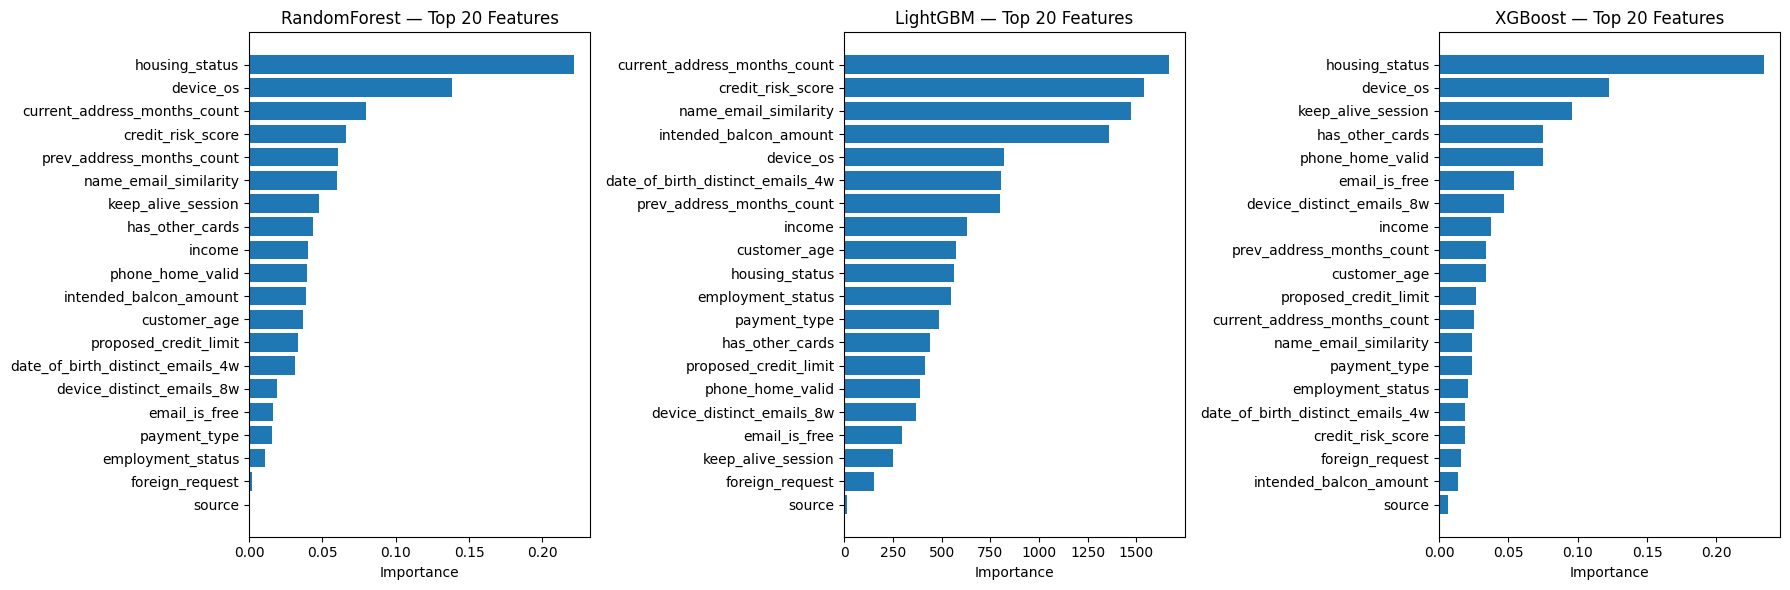

In [21]:
tree_models = {k: v["model"] for k, v in results.items()
               if k in ("RandomForest", "LightGBM", "XGBoost")}

fig, axes = plt.subplots(1, len(tree_models), figsize=(6 * len(tree_models), 6))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]
    top_n = min(20, len(feature_cols))
    idx = order[:top_n]
    ax.barh([feature_cols[i] for i in idx[::-1]], importances[idx[::-1]])
    ax.set_title(f"{name} — Top {top_n} Features")
    ax.set_xlabel("Importance")

fig.tight_layout()
fig.savefig(f"{MODEL_OUT_DIR}/figures/feature_importance.png", dpi=150)
plt.show()
print("Saved feature_importance.png")

## 9. Best Parameters Summary

In [ ]:
for name, params in best_params.items():
    print(f"{name}:")
    for k, v in params.items():
        print(f"  {k}: {v}")
    print()

## 10. Precision-Recall Curves — Validation Set

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
baseline = y_val.mean()
ax.axhline(baseline, color="gray", linestyle="--",
           label=f"Baseline (prevalence={baseline:.4f})")

for name, r in results.items():
    y_proba = r["model"].predict_proba(X_val)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall, precision,
            label=f"{name} (AUPRC={r['val_auprc']:.3f}, Best F1={r['best_f1']:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Validation Set (Tuned Models)")
ax.legend(loc="upper right")
fig.tight_layout()

os.makedirs(f"{MODEL_OUT_DIR}/figures", exist_ok=True)
fig.savefig(f"{MODEL_OUT_DIR}/figures/pr_curves_val.png", dpi=150)
plt.show()

## 11. Save Tuned Models & Best Thresholds

In [ ]:
thresholds = {}

for name, r in results.items():
    model_path = os.path.join(MODEL_OUT_DIR, f"{name}.joblib")
    joblib.dump(r["model"], model_path)
    thresholds[name] = r["best_thresh"]
    print(f"Saved {name} → {model_path}  (best threshold: {r['best_thresh']:.4f})")

joblib.dump(thresholds, os.path.join(MODEL_OUT_DIR, "best_thresholds.joblib"))
print("\nSaved best_thresholds.joblib")
print(f"\nBest model: {best_name}")
print("Run MODELS/evaluate.py for final test-set evaluation.")